In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hazing-images-dataset-cvpr-2019/GT/41_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/49_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/21_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/15_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/36_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/42_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/18_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/48_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/25_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/52_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/29_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/45_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/20_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/50_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/16_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/33_GT.png
/kaggle/input/hazing-images-dataset-cvpr-2019/GT/10_GT.p

# Import Libraries

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import cv2
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import plot_model, img_to_array

from IPython import display
from PIL import Image

# Load Data

In [ ]:
gt_train_images_path = "/kaggle/input/hazing-images-dataset-cvpr-2019/GT"
hazy_train_images_path = "/kaggle/input/hazing-images-dataset-cvpr-2019/hazy"

In [ ]:
gt_test_images_path = "/kaggle/input/hazing-images-dataset-cvpr-2019//GT"
hazy_test_images_path = "/kaggle/input/hazing-images-dataset-cvpr-2019/hazy"

In [ ]:
SIZE = 256

In [ ]:
def load_images(path, size=224, count=None):
    files = os.listdir(path)

    files.sort()
    if count is not None:
        files = os.listdir(path)[:count]
    images = []

    for file in tqdm.tqdm(files):
        img_path = os.path.join(path, file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (size, size))
        img = img.astype("float32") / 255.
        img = img_to_array(img)
        images.append(img)

    images = np.array(images)
    return images

In [15]:
train_gt_images = load_images(gt_train_images_path, size=SIZE)

100%|██████████| 55/55 [00:03<00:00, 13.85it/s]


In [16]:
train_hazy_images = load_images(hazy_train_images_path, size=SIZE)

100%|██████████| 55/55 [00:03<00:00, 17.04it/s]


In [17]:
test_gt_images = load_images(gt_test_images_path, size=SIZE)

100%|██████████| 55/55 [00:03<00:00, 14.75it/s]


In [18]:
test_hazy_images = load_images(hazy_test_images_path, size=SIZE)

100%|██████████| 55/55 [00:02<00:00, 18.81it/s]


# Visualization

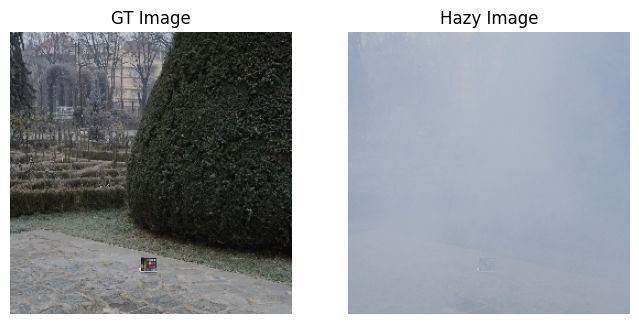

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))

axes[0].imshow(train_gt_images[10])
axes[0].set_title("GT Image")
axes[0].axis("off")

axes[1].imshow(train_hazy_images[10])
axes[1].set_title("Hazy Image")
axes[1].axis("off")

plt.show()

# Model

In [ ]:
def unet_model(input_shape=(256,256,3)):
    inputs = layers.Input(shape=input_shape)

    #Encoder (DownSampling)------>
    c1 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)



    #BottleNeck
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)

    #Decoder
    u5 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c4)
    # Skip Connection: Concatenate u5 with c3
    u5 = layers.concatenate([u5, c3]) 
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    # Skip Connection: Concatenate u6 with c2
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    # Skip Connection: Concatenate u7 with c1
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    # Output Layer
    outputs = layers.Conv2D(3, (1, 1), activation='sigmoid')(c7) # Use 'linear' if targets are not 0-1

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Instantiate
autoencoder = unet_model(input_shape=(256, 256, 3)) 
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()





I0000 00:00:1768147921.392860      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768147921.393487      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    524,544 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │    131,200 │ conv2d_9[0][0]  

 Total params: 7,697,475 (29.36 MB)

 Trainable params: 7,697,475 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = unet_model(input_shape=(256, 256, 3))

In [ ]:
model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss="mae")
model.summary()    

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 128, 128,  │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_17[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_4[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_19[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_5[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │  2,359,808 │ conv2d_21[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 64, 64,    │    524,544 │ conv2d_22[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │  1,179,904 │ concatenate_3[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_23[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 128, 128,  │    131,200 │ conv2d_24[0][0] 

 Total params: 7,697,475 (29.36 MB)

 Trainable params: 7,697,475 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

# Train

In [30]:

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    train_hazy_images, 
    train_gt_images, 
    batch_size = 8, 
    epochs = 50,
    callbacks=[reduce_lr]
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - loss: 0.1677 - learning_rate: 0.0010
Epoch 2/50


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - loss: 0.1603 - learning_rate: 0.0010
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - loss: 0.1732 - learning_rate: 0.0010
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step - loss: 0.1693 - learning_rate: 0.0010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - loss: 0.1673 - learning_rate: 0.0010
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - loss: 0.1716 - learning_rate: 0.0010
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - loss: 0.1640 - learning_rate: 0.0010
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - loss: 0.1763 - learning_rate: 0.0010
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - loss: 0.1669 - learning_rate: 0.0010
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - loss: 0.1695 - learning_rate: 0.0010
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - loss: 0.1719 - learning_rate: 0.0010
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - loss: 0.1675 - learning_rate: 0.0010
Epoch 13/50
7/7 ━━━━━━━━━━━━━

In [ ]:
#plot_model(model, show_shapes=True, show_layer_names=True)

# Results

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss
0,0.195127
1,0.188728
2,0.187922
3,0.188058
4,0.184497


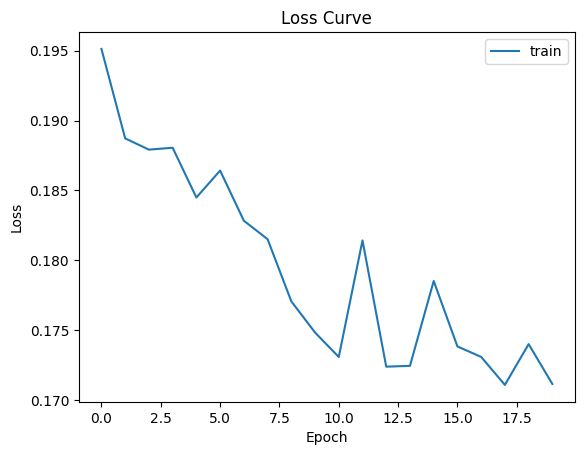

In [ ]:
plt.figure()
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend(["train"])
plt.show()

In [ ]:
def predict_images(test_gt, test_hazy, count=5, size=224):
    for _ in range(count):
        random_idx = np.random.randint(len(test_gt))
        predicted = model.predict(test_hazy[random_idx].reshape(1, size, size, 3), verbose=0)
        predicted = np.clip(predicted, 0.0, 1.0).reshape(size, size, 3)
        
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))
        
        axes[0].imshow(test_gt[random_idx])
        axes[0].set_title("GT Image")
        axes[0].axis("off")
        
        axes[1].imshow(test_hazy[random_idx])
        axes[1].set_title("Hazy Image")
        axes[1].axis("off")

        axes[2].imshow(predicted)
        axes[2].set_title("Predicted Image")
        axes[2].axis("off")
        
        plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_25']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


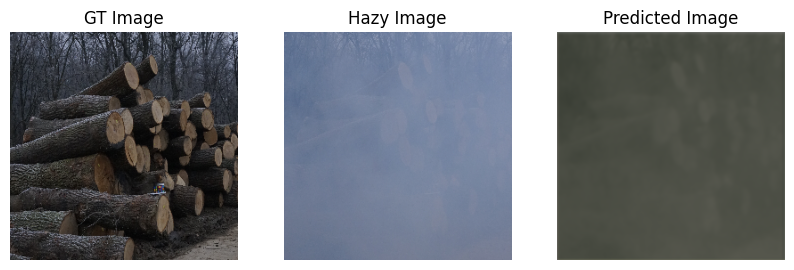

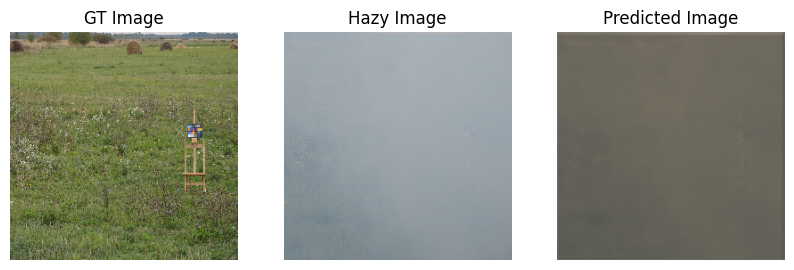

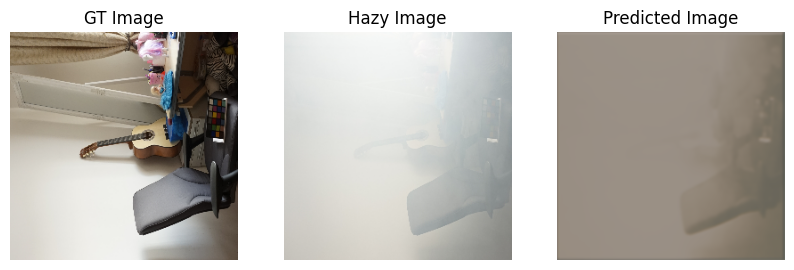

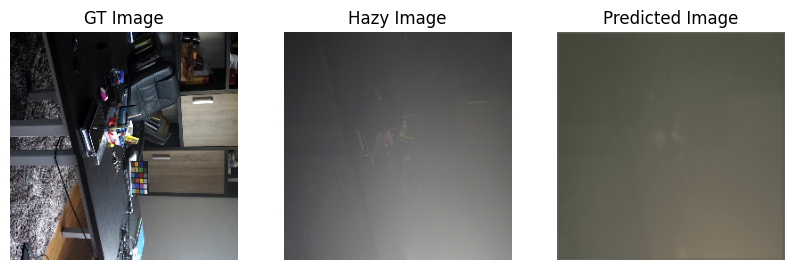

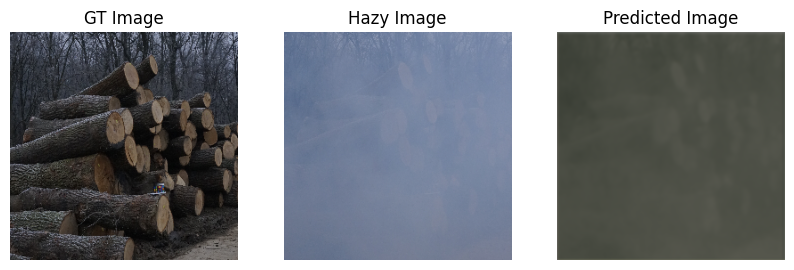

In [28]:
predict_images(test_gt_images, test_hazy_images, count=5, size=SIZE)